In [24]:
!pip3 install numpy matplotlib plotly nbformat


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# Cell 2: Thư viện cần thiết
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D


In [26]:
# Cell 3: Đọc dữ liệu
df = pd.read_csv('customer_data.csv')
df.head(1000)


,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,30,Female,18444,College,West,Regular,frequent,8090,Electronics,0,4
996,997,35,Male,23348,Bachelor,South,Regular,frequent,7912,Books,1,6
997,998,24,Male,7627,HighSchool,West,Regular,occasional,2561,Electronics,0,5
998,999,28,Male,47063,Bachelor,West,Silver,occasional,19203,Books,0,6


In [27]:
# Cell 4: Tiền xử lý
df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id']).head(10000)
print(df)


      age  income  purchase_amount  promotion_usage  satisfaction_score
0      27   40682            18249                0                   6
1      29   15317             4557                1                   6
2      37   38849            11822                0                   6
3      30   11568             4098                0                   7
4      31   46952            19685                1                   5
...   ...     ...              ...              ...                 ...
9995   25   10455             4265                1                   5
9996   28   42935            18728                0                   6
9997   27   21252             5940                1                   4
9998   35   36017            12173                0                   3
9999   27   41353            15041                1                   5

[10000 rows x 5 columns]


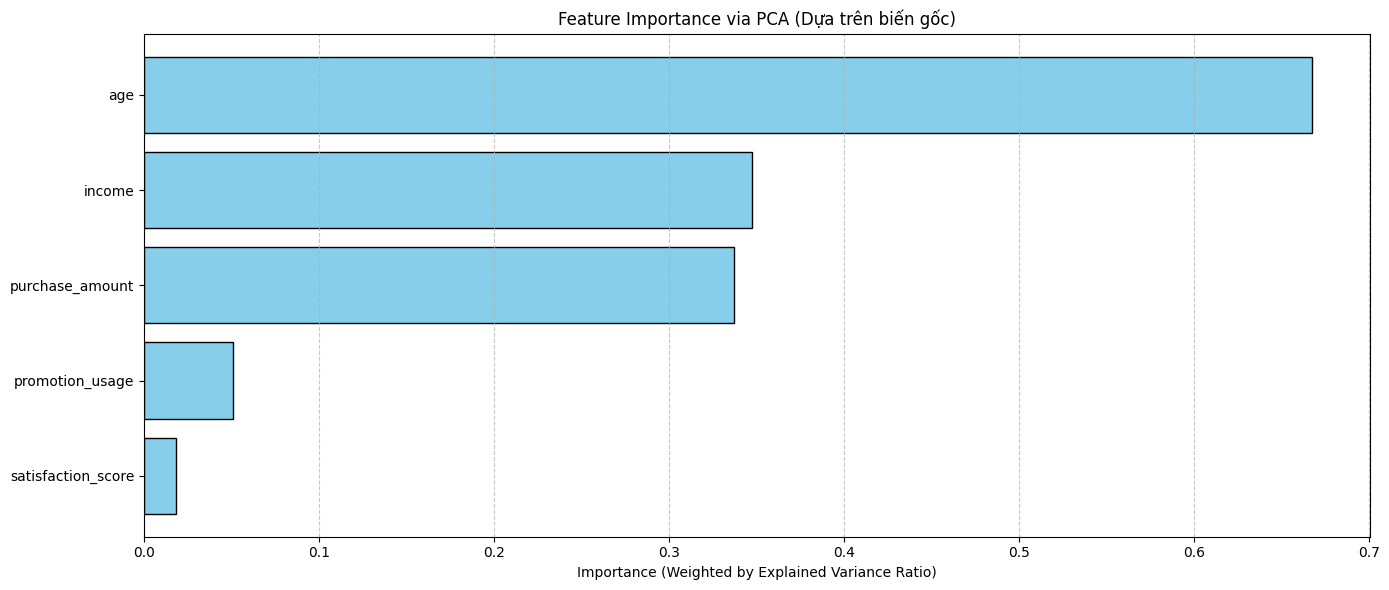

In [28]:

# Bước 1: PCA đầy đủ (full component)
df_encoded = df
categorical_num_cols = ['age','income','purchase_amount','satisfaction_score']  

scaler = StandardScaler()
df_encoded[categorical_num_cols] = scaler.fit_transform(df_encoded[categorical_num_cols])

pca = PCA()
X_pca = pca.fit_transform(df_encoded)

# Bước 2: Tính ma trận loading
loadings = pca.components_.T  # shape: (n_features, n_components)

# Bước 3: Tính importance của từng biến gốc
# Tổng tỉ trọng (weighted loading) trên tất cả các thành phần chính
importance_weighted = np.sum(
    (np.abs(loadings).T * pca.explained_variance_ratio_).T, axis=1
)

# Bước 4: Đưa vào DataFrame
feature_importance = pd.DataFrame({
    'Feature': df.columns,
    'Importance': importance_weighted
}).sort_values(by='Importance', ascending=True)

# Bước 5: Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='black')
plt.xlabel("Importance (Weighted by Explained Variance Ratio)")
plt.title("Feature Importance via PCA (Dựa trên biến gốc)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [29]:

import plotly.express as px

# Áp dụng PCA với 2 thành phần
pca = PCA(n_components=3)
data_pca = pca.fit_transform(df_encoded)

# In số chiều sau PCA
print(f"Số chiều sau PCA: {data_pca.shape[1]}")  # sẽ in ra 2

# Không cần cắt và không cần to_numpy vì đã là NumPy array
df_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2', 'PC3'])

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                    color_discrete_sequence=['blue'],
                    opacity=0.5)

fig.update_layout(title='Biểu đồ PCA 3D (tương tác)',
                      width=1200,
                    height=1800,
                  scene=dict(xaxis_title='PC1',
                             yaxis_title='PC2',
                             zaxis_title='PC3'))

fig.show()


Số chiều sau PCA: 3


In [30]:
class KMeans():
  def __init__(self, n_clusters, data):
    self.k = n_clusters
    self.x = data
    self.d = self.x[0].shape[0] # Dimension
    self.centroids = np.zeros((self.d, self.k))

    # Initializing K centroids within the data bounds
    # Respecting the different max and min of each axis
    for i in range(0, self.d):
        self.centroids[i] = np.random.uniform(low=np.min(self.x[:, i]), high=np.max(self.x[:, i]), size=(1, self.k))
    self.centroids = np.transpose(self.centroids)

    self.labels = self.genLabels()

    self.colors = {0:'red', 1:'blue', 2:'green', 3:'black', 4:'purple', 5:'orange', 6:'brown'}

  def dist(self, p, q):
    # Euclidean distance
    return np.sqrt(np.sum(np.power(np.subtract(p, q), 2)))

  def predict(self, p):
    return np.argmin([self.dist(p, centroid) for centroid in self.centroids])

  def genLabels(self):
    return np.asarray([self.predict(p) for p in self.x])

  def fit(self, epochs, step):
    print(f"\nFitting for {epochs} epochs with step of {step}")
    for epoch in range(0, epochs):
      for i, centroid in enumerate(self.centroids):
        l = [1 if item == i else 0 for item in self.labels]
        temp = np.matmul(np.transpose(np.subtract(self.x, centroid)), np.transpose(l))
        self.centroids[i] += np.matmul([step], np.divide(temp.reshape(1, self.d), sum(l)))

        # Regenerate the labels
        self.labels = self.genLabels()

    print("Done fitting!\n")

  def showPlot(self, classification=False):
      fig = plt.figure(figsize=(10, 10))
      ax = fig.add_subplot(111, projection='3d')

      handles = []  # Danh sách chú thích

      if classification:
          for i, p in enumerate(self.x):
              ax.scatter(p[0], p[1], p[2], color=self.colors[self.labels[i]])

          for i, centroid in enumerate(self.centroids):
              ax.scatter(centroid[0], centroid[1], centroid[2],
                        color=self.colors[i], s=200, marker="x",
                        edgecolor='black', linewidths=2)

              # Thêm đối tượng Line2D vào danh sách để tạo chú thích
              handles.append(Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=self.colors[i],
                                    markeredgecolor='black',
                                    markersize=10, label=f"Cluster {i}"))

          # Hiển thị chú thích
          ax.legend(handles=handles, loc='upper left', title="Clusters")

      else:
          ax.scatter(self.x[:, 0], self.x[:, 1], self.x[:, 2], color='blue', label='Data Points')
          ax.scatter(self.centroids[:, 0], self.centroids[:, 1], self.centroids[:, 2],
                    color="red", s=100, marker="x", label='Centroids')

          ax.legend(loc='upper left')

      ax.set_title("KMeans Clustering Visualization (3D)")
      plt.show()

  def printCentroids(self):
    print("="*20)
    print("Centroids:")
    print(self.centroids)

  def calculate_wcss(self):
    """Calculate the Within-Cluster Sum of Squares (WCSS)."""
    wcss = 0
    for i, centroid in enumerate(self.centroids):
        cluster_points = self.x[self.labels == i]  # Points assigned to the current centroid
        wcss += np.sum([self.dist(p, centroid) ** 2 for p in cluster_points])
    return wcss
  

In [31]:
def elbow_curve(X, max_k):
    wcss_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, data=X)
        kmeans.fit(epochs=100, step=1)  # Fit the model
        wcss = kmeans.calculate_wcss()    # Calculate WCSS for this k
        wcss_values.append(wcss)

    # Plotting the elbow curve
    plt.plot(range(1, max_k + 1), wcss_values, marker='o', color='b')
    plt.title('Elbow Curve')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.show()


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!


Fitting for 100 epochs with step of 1
Done fitting!



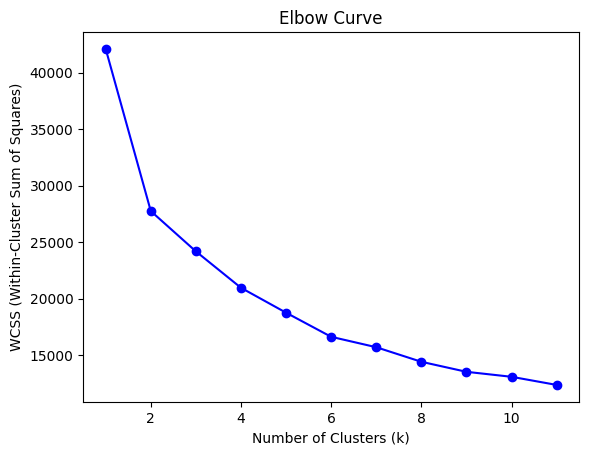

In [33]:
elbow_curve(X_pca, 11)

C:\Users\levie\AppData\Local\Temp\ipykernel_4888\2819933627.py:52: UserWarning:

You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.



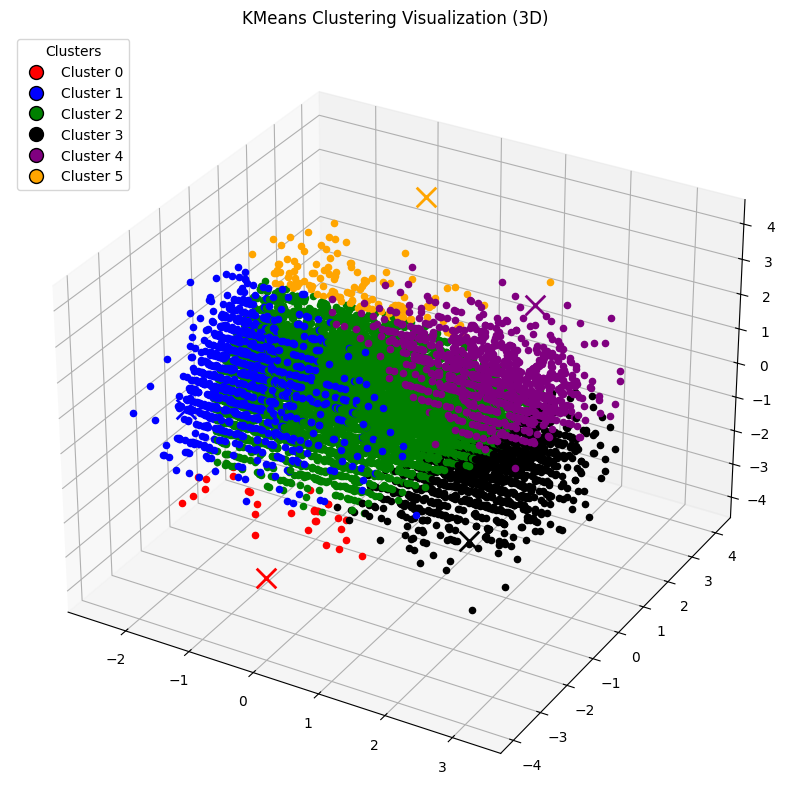

Centroids:
[[-0.67332852 -2.49350449 -3.74887535  0.44313727 -0.32720934]
 [-2.01395946 -2.21207009  0.21929715 -0.01743403  0.96508854]
 [-0.70591402 -0.36446673 -0.78819307 -0.06224841 -1.13269077]
 [ 1.62674347 -0.5305328  -2.74693408 -0.01266279 -0.66280727]
 [ 1.9176424   1.14654733  3.03984035 -0.30836802 -1.43168127]
 [-0.61795425  3.28188702  3.50640641  0.18397915 -0.83456054]]

Fitting for 100 epochs with step of 0.1
Done fitting!

Centroids:
[[-1.08607525 -0.77829062 -0.90734731 -0.00509744  0.00652614]
 [-1.11264335 -0.87602381  0.75737178  0.01510295  0.01402392]
 [-0.52201816  0.9443682  -0.73960325 -0.00187929 -0.00599738]
 [ 1.40393343 -0.2468021  -0.69041321 -0.00387669 -0.00318376]
 [ 1.28197606  0.17708709  0.85264946  0.0118657  -0.02175107]
 [-1.31375374  0.80140057  0.67705734 -0.02005283  0.02162486]]


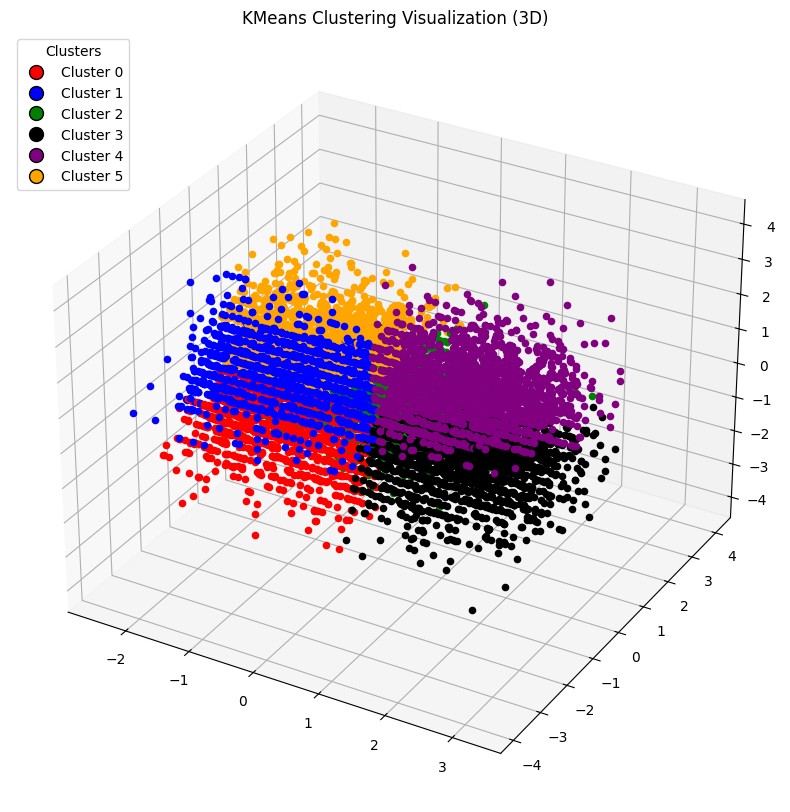

In [35]:
kmeans = KMeans(n_clusters=6, data=X_pca)
kmeans.showPlot(classification=True)
kmeans.printCentroids()
kmeans.fit(epochs=100, step=0.1)
kmeans.printCentroids()
kmeans.showPlot(classification=True)
# 3d scatterplot using plotly
Scene = dict(xaxis = dict(title  = 'Age -->'),yaxis = dict(title  = 'Spending Score--->'),zaxis = dict(title  = 'Annual Income-->'))

# model.labels_ is nothing but the predicted clusters i.e y_clusters
trace = go.Scatter3d(x=x[:, 0], y=x[:, 1], z=x[:, 2], mode='markers', marker=dict(color = kmeans.labels, size= 5, line=dict(color= 'black',width = 10)))
layout = go.Layout(margin=dict(l=0,r=0),scene = Scene,height = 800,width = 800)
data = [trace]
fig = go.Figure(data = data, layout = layout)
fig.show()